In [2]:
import pandas as pd

In [8]:
store_df = pd.read_csv('data/store.csv')

data = pd.read_csv('data/train.csv', low_memory = False)

In [4]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [13]:
store_df.shape

(1115, 10)

In [9]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [14]:
data.shape

(1017209, 9)

In [6]:
store_df['Store'].value_counts()

Store
1       1
2       1
3       1
4       1
5       1
       ..
1111    1
1112    1
1113    1
1114    1
1115    1
Name: count, Length: 1115, dtype: int64

In [10]:
data['Store'].value_counts()

Store
1       942
2       942
3       942
4       942
5       942
       ... 
1094    758
1102    758
1104    758
1107    758
1109    758
Name: count, Length: 1115, dtype: int64

In [44]:
df = data.merge(store_df, on = 'Store', how = 'left')

In [12]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [15]:
df.shape

(1017209, 18)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [17]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

Rimuovo righe con valori nulli sotto il 5 % del totale del dataframe : Competition Distance

In [18]:
len(df) * 5 / 100

50860.45

In [45]:
df = df.dropna(subset = ['CompetitionDistance'])

In [46]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth    320706
CompetitionOpenSinceYear     320706
Promo2                            0
Promo2SinceWeek              506147
Promo2SinceYear              506147
PromoInterval                506147
dtype: int64

In [26]:
df['PromoInterval'].value_counts()

PromoInterval
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     117838
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64

In [39]:
df['PromoInterval'] = df['PromoInterval'].fillna('-1')

In [126]:
df['PromoInterval'].value_counts()

PromoInterval
-1                  405468
Jan,Apr,Jul,Oct     232347
Feb,May,Aug,Nov      93506
Mar,Jun,Sept,Dec     77471
Name: count, dtype: int64

In [124]:
intervals = {
    '-1':-1,
    'Jan,Apr,Jul,Oct':1,
    'Feb,May,Aug,Nov':2,
    'Mar,Jun,Sept,Dec':3
}


df['PromoTestInterval'] = df['PromoInterval'].map(intervals)

In [125]:
df['PromoTestInterval'].value_counts()

PromoTestInterval
-1    405468
 1    232347
 2     93506
 3     77471
Name: count, dtype: int64

In [47]:
df.drop(['Promo2SinceWeek', 'Promo2SinceYear'], axis = 1, inplace = True)

In [48]:
df.dtypes

Store                          int64
DayOfWeek                      int64
Date                             str
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                     str
SchoolHoliday                  int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
PromoInterval                    str
dtype: object

In [49]:
df['CompetitionOpenSinceMonth'].value_counts()

CompetitionOpenSinceMonth
9.0     114254
4.0      87076
11.0     84455
3.0      63548
7.0      59434
12.0     57896
10.0     55622
6.0      45444
5.0      39608
2.0      37886
8.0      36186
1.0      12452
Name: count, dtype: int64

In [51]:
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(df['CompetitionOpenSinceMonth'].min())

In [50]:
df['CompetitionOpenSinceYear'].value_counts()

CompetitionOpenSinceYear
2013.0    75426
2012.0    74299
2014.0    63732
2005.0    56564
2010.0    51258
2009.0    49396
2011.0    49396
2008.0    48476
2007.0    43744
2006.0    42802
2015.0    35060
2002.0    24882
2004.0    19804
2003.0    16794
2001.0    14704
2000.0     9236
1999.0     7352
1990.0     4710
1994.0     1884
1995.0     1700
1961.0      942
1998.0      942
1900.0      758
Name: count, dtype: int64

In [52]:
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(df['CompetitionOpenSinceYear'].min())

In [54]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
PromoInterval                506147
dtype: int64

In [55]:
df['PromoInterval'] = df['PromoInterval'].fillna('-1')

In [56]:
df.isna().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
PromoInterval                0
dtype: int64

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

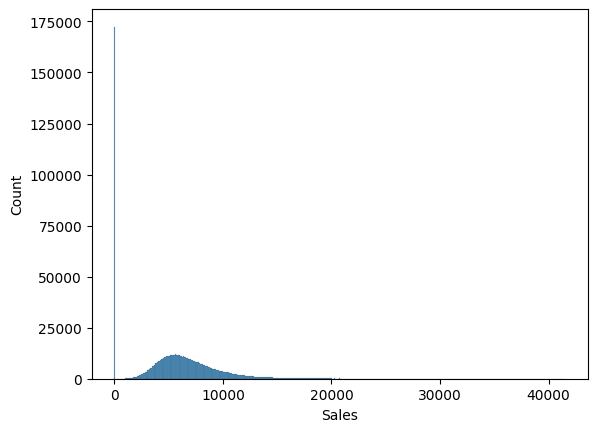

In [58]:
sns.histplot(df['Sales'])
plt.show()

In [59]:
import numpy as np

In [65]:
df[df['Sales'] == 0]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,PromoInterval
291,292,5,2015-07-31,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,-1
875,876,5,2015-07-31,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,"Feb,May,Aug,Nov"
1406,292,4,2015-07-30,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,-1
1990,876,4,2015-07-30,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,"Feb,May,Aug,Nov"
2521,292,3,2015-07-29,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,-1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,1.0,1900.0,0,-1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,1.0,1900.0,0,-1


In [66]:
df = df[df['Sales'] != 0]

In [67]:
df.shape

(842152, 16)

In [68]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,-1
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,-1
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,-1


In [69]:
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')

In [70]:
df['DayOfWeek'].value_counts()

DayOfWeek
6    143676
2    143581
3    141555
5    138272
1    137200
4    134275
7      3593
Name: count, dtype: int64

In [ ]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x>=6 else 0)
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [83]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,IsSchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,PromoInterval,Day,Month,Year,IsWeekend,WeekOfYear
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,720.0,3.0,2002.0,0,-1,1,1,2013,0,1
1,512,2,2013-01-01,2646,625,1,0,a,1,b,...,590.0,1.0,1900.0,1,"Mar,Jun,Sept,Dec",1,1,2013,0,1
2,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,1430.0,1.0,1900.0,0,-1,1,1,2013,0,1
3,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,840.0,1.0,1900.0,1,"Jan,Apr,Jul,Oct",1,1,2013,0,1
4,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,860.0,10.0,1999.0,0,-1,1,1,2013,0,1


In [76]:
df.sort_values('Date', ascending= True, inplace=True, ignore_index=True)

In [77]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,PromoInterval,Day,Month,Year,IsWeekend
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,-1,1,1,2013,0
1,512,2,2013-01-01,2646,625,1,0,a,1,b,b,590.0,1.0,1900.0,1,"Mar,Jun,Sept,Dec",1,1,2013,0
2,948,2,2013-01-01,4491,1039,1,0,a,1,b,b,1430.0,1.0,1900.0,0,-1,1,1,2013,0
3,769,2,2013-01-01,5035,1248,1,0,a,1,b,b,840.0,1.0,1900.0,1,"Jan,Apr,Jul,Oct",1,1,2013,0
4,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10.0,1999.0,0,-1,1,1,2013,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842147,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,4.0,2013.0,0,-1,31,7,2015,0
842148,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,12.0,2013.0,0,-1,31,7,2015,0
842149,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,-1,31,7,2015,0
842150,11,5,2015-07-31,10457,1236,1,1,0,1,a,c,960.0,11.0,2011.0,1,"Jan,Apr,Jul,Oct",31,7,2015,0


In [ ]:
df.rename(columns= {'SchoolHoliday':'IsSchoolHoliday'}, inplace = True)

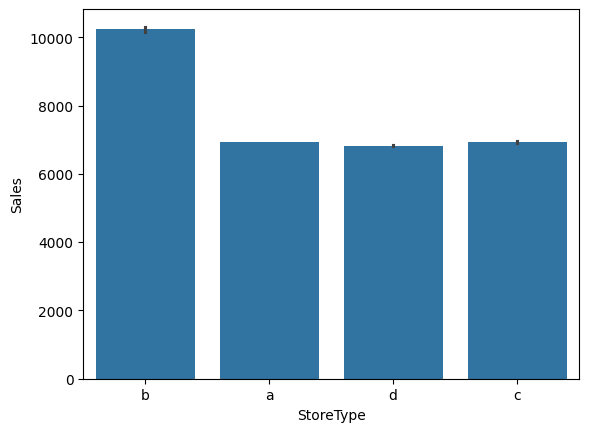

In [88]:
sns.barplot( x = 'StoreType', y = 'Sales', data = df)
plt.show()

In [81]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,IsSchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,PromoInterval,Day,Month,Year,IsWeekend
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,-1,1,1,2013,0
1,512,2,2013-01-01,2646,625,1,0,a,1,b,b,590.0,1.0,1900.0,1,"Mar,Jun,Sept,Dec",1,1,2013,0
2,948,2,2013-01-01,4491,1039,1,0,a,1,b,b,1430.0,1.0,1900.0,0,-1,1,1,2013,0
3,769,2,2013-01-01,5035,1248,1,0,a,1,b,b,840.0,1.0,1900.0,1,"Jan,Apr,Jul,Oct",1,1,2013,0
4,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10.0,1999.0,0,-1,1,1,2013,0


In [89]:
df.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[us]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                            str
IsSchoolHoliday                       int64
StoreType                               str
Assortment                              str
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
PromoInterval                           str
Day                                   int32
Month                                 int32
Year                                  int32
IsWeekend                             int64
WeekOfYear                           UInt32
dtype: object

In [90]:
df['CompetitionOpenDate'] = pd.to_datetime(
    dict(
        year=df['CompetitionOpenSinceYear'],
        month=df['CompetitionOpenSinceMonth'],
        day=1
    )
)

df['CompetitionOpenMonths'] = (
    (df['Date'].dt.year - df['CompetitionOpenDate'].dt.year) * 12 +
    (df['Date'].dt.month - df['CompetitionOpenDate'].dt.month)
)

In [92]:
df.drop(['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'], axis = 1, inplace = True)

In [93]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,IsSchoolHoliday,StoreType,...,CompetitionDistance,Promo2,PromoInterval,Day,Month,Year,IsWeekend,WeekOfYear,CompetitionOpenDate,CompetitionOpenMonths
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,720.0,0,-1,1,1,2013,0,1,2002-03-01,130
1,512,2,2013-01-01,2646,625,1,0,a,1,b,...,590.0,1,"Mar,Jun,Sept,Dec",1,1,2013,0,1,1900-01-01,1356
2,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,1430.0,0,-1,1,1,2013,0,1,1900-01-01,1356
3,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,840.0,1,"Jan,Apr,Jul,Oct",1,1,2013,0,1,1900-01-01,1356
4,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,860.0,0,-1,1,1,2013,0,1,1999-10-01,159


In [123]:
df.groupby('Store')['Sales'].mean()

Store
1        4745.324900
2        4971.401857
3        6956.532710
4        9649.932361
5        4692.750334
            ...     
1111     5257.546061
1112    10155.986649
1113     6648.848806
1114    20771.718833
1115     6368.782956
Name: Sales, Length: 1112, dtype: float64

In [121]:
df.groupby('Store')['Sales'].shift(1)

30            NaN
31         6140.0
32         5499.0
33         5681.0
34         5370.0
           ...   
842147     6897.0
842148    10712.0
842149     8093.0
842150     7661.0
842151     8405.0
Name: Sales, Length: 808792, dtype: float64

In [97]:
# ============================================================
# 1. Ordina per Store e Date — fondamentale per lag e rolling
# ============================================================
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# ============================================================
# 2. Calcola le feature temporali SULL'INTERO df
#    È sicuro perché shift() usa solo valori PASSATI
# ============================================================

# --- Lag features ---
df['Sales_lag_1']  = df.groupby('Store')['Sales'].shift(1)
df['Sales_lag_7']  = df.groupby('Store')['Sales'].shift(7)
df['Sales_lag_30'] = df.groupby('Store')['Sales'].shift(30)

# --- Rolling mean (shift(1) prima per escludere il giorno corrente) ---
df['Sales_rolling_7'] = (
    df.groupby('Store')['Sales']
    .shift(1)
    .rolling(7).mean()
    .reset_index(0, drop=True)
)
df['Sales_rolling_30'] = (
    df.groupby('Store')['Sales']
    .shift(1)
    .rolling(30).mean()
    .reset_index(0, drop=True)
)

# ============================================================
# 3. Rimuovi le righe con NaN dovuti ai lag (solo inizio storia)
#    Queste saranno tutte nel train set, non nel test
# ============================================================
df = df.dropna(subset=['Sales_lag_1', 'Sales_lag_7', 'Sales_lag_30',
                        'Sales_rolling_7', 'Sales_rolling_30'])

# ============================================================
# 4. Split temporale — MAI shuffle con serie temporali
# ============================================================
split_date = '2015-06-01'

train = df[df['Date'] < split_date].copy()
test  = df[df['Date'] >= split_date].copy()

# ============================================================
# 5. Separa feature e target
# ============================================================
drop_cols = ['Sales', 'Date']

X_train = train.drop(columns=drop_cols)
y_train = train['Sales']

X_test  = test.drop(columns=drop_cols)
y_test  = test['Sales']

print(f"Train: {train['Date'].min().date()} → {train['Date'].max().date()} ({len(train)} righe)")
print(f"Test:  {test['Date'].min().date()} → {test['Date'].max().date()} ({len(test)} righe)")

Train: 2013-01-31 → 2015-05-31 (750339 righe)
Test:  2015-06-01 → 2015-07-31 (58453 righe)


In [99]:
X_train.dtypes

Store                             int64
DayOfWeek                         int64
Customers                         int64
Open                              int64
Promo                             int64
StateHoliday                        str
IsSchoolHoliday                   int64
StoreType                           str
Assortment                          str
CompetitionDistance             float64
Promo2                            int64
PromoInterval                       str
Day                               int32
Month                             int32
Year                              int32
IsWeekend                         int64
WeekOfYear                       UInt32
CompetitionOpenDate      datetime64[us]
CompetitionOpenMonths             int32
Sales_lag_1                     float64
Sales_lag_7                     float64
Sales_lag_30                    float64
Sales_rolling_7                 float64
Sales_rolling_30                float64
dtype: object

In [102]:
X_train.head()

,Store,DayOfWeek,Customers,Promo,StateHoliday,IsSchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,...,Month,Year,IsWeekend,WeekOfYear,CompetitionOpenMonths,Sales_lag_1,Sales_lag_7,Sales_lag_30,Sales_rolling_7,Sales_rolling_30
30,1,3,693,1,0,0,c,a,1270.0,0,...,2,2013,0,6,53,6049.0,3725.0,5530.0,5388.428571,5103.833333
31,1,4,675,1,0,0,c,a,1270.0,0,...,2,2013,0,6,53,6140.0,4601.0,4327.0,5733.428571,5124.166667
32,1,5,630,1,0,0,c,a,1270.0,0,...,2,2013,0,6,53,5499.0,4709.0,4486.0,5861.714286,5163.233333
33,1,6,656,0,0,0,c,a,1270.0,0,...,2,2013,1,6,53,5681.0,5633.0,4997.0,6000.571429,5203.066667
34,1,1,599,0,0,0,c,a,1270.0,0,...,2,2013,0,7,53,5370.0,5970.0,7176.0,5963.000000,5215.500000


In [101]:
cols_to_drop = ['CompetitionOpenDate', 'Open']

X_train.drop(cols_to_drop, axis = 1, inplace = True)
X_test.drop(cols_to_drop, axis = 1, inplace = True)

In [104]:
target_enc = ['Store']

label_enc = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']

cat_col = ['Store', 'StateHoliday', 'StoreType', 'Assortment', 'PromoInterval',]

In [105]:
for col in cat_col:
    df[col] = df[col].astype('category')

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline

In [114]:
from sklearn.ensemble import RandomForestRegressor

In [115]:
preprocessor = ColumnTransformer(transformers=[
    ('lab', OrdinalEncoder(),label_enc),
    ('target_enc', TargetEncoder(), target_enc)
])

model = RandomForestRegressor( 
    n_estimators= 100,
    max_depth= 6,
    max_features= 'sqrt'
)
pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', model)
])


In [116]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('lab', ...), ('target_enc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [118]:
y_pred = pipeline.predict(X_test)

In [119]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [120]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print(r2, mae, rmse)

0.13523638607399724 2132.307170092291 2893.7508177438185
